# Deteksi Website Phishing dengan Deep Learning

Notebook ini membandingkan **3 arsitektur Deep Learning** (ANN/MLP, CNN 1D, dan LSTM)
untuk mengklasifikasikan sebuah website sebagai **Phishing** atau **Legitimate (Aman)**
berdasarkan 30 fitur URL & website yang sudah diekstrak sebelumnya.

**Dataset:** UCI Phishing Websites Dataset (`phishing.csv`) — 11.054 baris, 30 fitur kategorikal
(bernilai -1, 0, atau 1) + 1 kolom target `class`.

**Alur notebook:**
1. Import library & load dataset
2. Exploratory Data Analysis (EDA)
3. Preprocessing (split, scaling, reshaping)
4. Membangun 3 model Deep Learning: **ANN**, **CNN 1D**, **LSTM**
5. Training & training curve tiap model
6. Evaluasi lengkap: Confusion Matrix (TP, TN, FP, FN) + TPR, TNR, FPR, FNR, PPV, NPV, Accuracy
7. Visualisasi perbandingan seluruh metrik ketiga model
8. Menyimpan model & artefak terbaik untuk dipakai di aplikasi web (Streamlit)

## 1. Import Library & Setup

In [1]:
import os
import json
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

import joblib

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

# Folder untuk menyimpan model & artefak hasil training
ARTIFACT_DIR = "streamlit_app/models"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

TensorFlow version: 2.21.0
Keras version: 3.12.1


## 2. Load Dataset

In [2]:
df = pd.read_csv("dataset/phishing.csv")

# Kolom 'Index' hanya nomor urut, tidak relevan sebagai fitur
if "Index" in df.columns:
    df = df.drop(columns=["Index"])

print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (11054, 31)


,UsingIP,LongURL,ShortURL,Symbol@,Redirecting//,PrefixSuffix-,SubDomains,HTTPS,DomainRegLen,Favicon,...,UsingPopupWindow,IframeRedirection,AgeofDomain,DNSRecording,WebsiteTraffic,PageRank,GoogleIndex,LinksPointingToPage,StatsReport,class
0,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
1,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
2,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
3,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1
4,-1,0,-1,1,-1,-1,1,1,-1,1,...,1,1,1,1,1,-1,1,-1,-1,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11054 entries, 0 to 11053
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   UsingIP              11054 non-null  int64
 1   LongURL              11054 non-null  int64
 2   ShortURL             11054 non-null  int64
 3   Symbol@              11054 non-null  int64
 4   Redirecting//        11054 non-null  int64
 5   PrefixSuffix-        11054 non-null  int64
 6   SubDomains           11054 non-null  int64
 7   HTTPS                11054 non-null  int64
 8   DomainRegLen         11054 non-null  int64
 9   Favicon              11054 non-null  int64
 10  NonStdPort           11054 non-null  int64
 11  HTTPSDomainURL       11054 non-null  int64
 12  RequestURL           11054 non-null  int64
 13  AnchorURL            11054 non-null  int64
 14  LinksInScriptTags    11054 non-null  int64
 15  ServerFormHandler    11054 non-null  int64
 16  InfoEmail            1

In [4]:
# Cek missing value & duplikat
print("Jumlah missing value :", df.isna().sum().sum())

Jumlah missing value : 0


## 3. Exploratory Data Analysis (EDA)

class
 1    6157
-1    4897
Name: count, dtype: int64


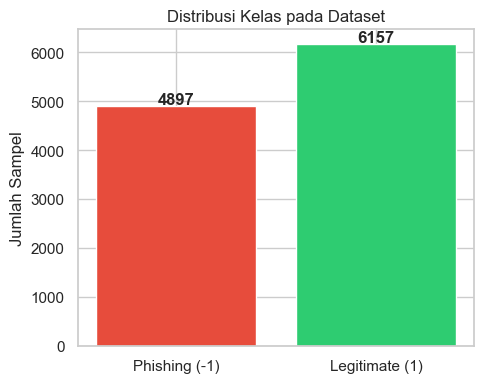

In [5]:
# Distribusi kelas target.
# Konvensi dataset ini: class = 1 -> Legitimate (situs aman), class = -1 -> Phishing
print(df["class"].value_counts())

fig, ax = plt.subplots(figsize=(5, 4))
counts = df["class"].value_counts().sort_index()
labels = ["Phishing (-1)", "Legitimate (1)"]
colors = ["#e74c3c", "#2ecc71"]
ax.bar(labels, counts.values, color=colors)
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, str(v), ha="center", fontweight="bold")
ax.set_title("Distribusi Kelas pada Dataset")
ax.set_ylabel("Jumlah Sampel")
plt.tight_layout()
plt.savefig("assets_class_distribution.png", bbox_inches="tight")
plt.show()

In [6]:
# Ringkasan statistik seluruh fitur (semua fitur bersifat kategorikal -1/0/1)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UsingIP,11054.0,0.313914,0.949495,-1.0,-1.0,1.0,1.0,1.0
LongURL,11054.0,-0.633345,0.765973,-1.0,-1.0,-1.0,-1.0,1.0
ShortURL,11054.0,0.738737,0.674024,-1.0,1.0,1.0,1.0,1.0
Symbol@,11054.0,0.700561,0.713625,-1.0,1.0,1.0,1.0,1.0
Redirecting//,11054.0,0.741632,0.670837,-1.0,1.0,1.0,1.0,1.0
PrefixSuffix-,11054.0,-0.734938,0.678165,-1.0,-1.0,-1.0,-1.0,1.0
SubDomains,11054.0,0.064049,0.817492,-1.0,-1.0,0.0,1.0,1.0
HTTPS,11054.0,0.251040,0.911856,-1.0,-1.0,1.0,1.0,1.0
DomainRegLen,11054.0,-0.336711,0.941651,-1.0,-1.0,-1.0,1.0,1.0
Favicon,11054.0,0.628551,0.777804,-1.0,1.0,1.0,1.0,1.0


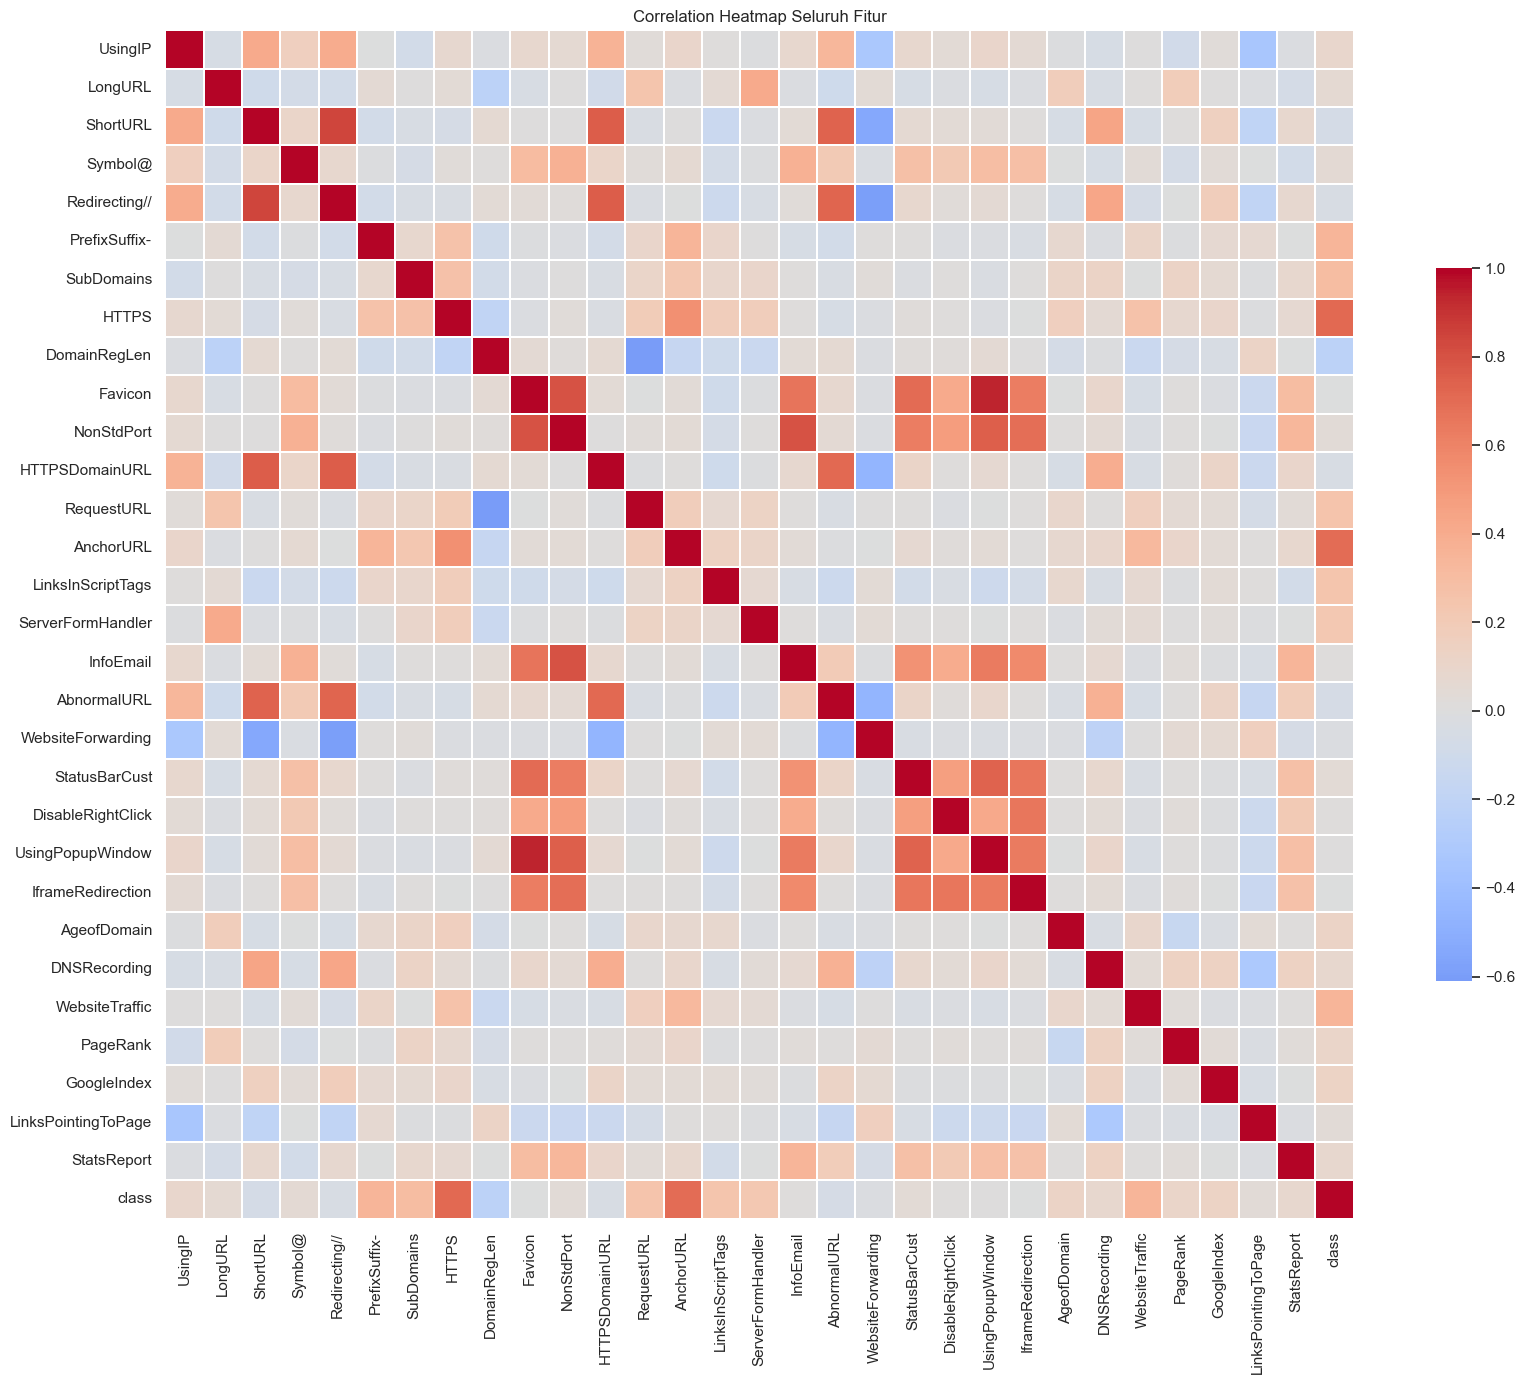

In [7]:
# Correlation heatmap antar fitur (termasuk target) untuk melihat fitur yang paling
# berkorelasi dengan label phishing/legitimate
plt.figure(figsize=(18, 14))
corr = df.corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3, square=True,
            cbar_kws={"shrink": 0.6})
plt.title("Correlation Heatmap Seluruh Fitur")
plt.tight_layout()
plt.savefig("assets_correlation_heatmap.png", bbox_inches="tight")
plt.show()

10 fitur paling berkorelasi dengan target:
HTTPS                0.714704
AnchorURL            0.692895
PrefixSuffix-        0.348588
WebsiteTraffic       0.346003
SubDomains           0.298231
RequestURL           0.253478
LinksInScriptTags    0.248415
DomainRegLen         0.225879
ServerFormHandler    0.221380
GoogleIndex          0.129000
Name: class, dtype: float64


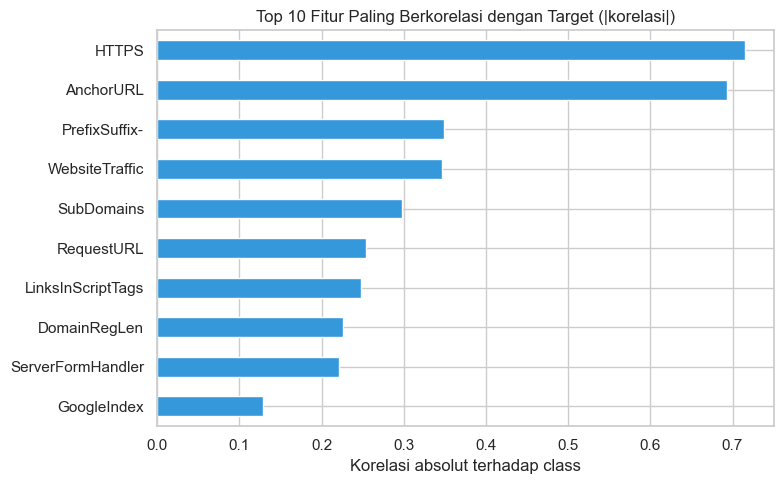

In [8]:
# 10 fitur dengan korelasi absolut tertinggi terhadap target 'class'
top_corr = corr["class"].drop("class").abs().sort_values(ascending=False).head(10)
print("10 fitur paling berkorelasi dengan target:")
print(top_corr)

fig, ax = plt.subplots(figsize=(8, 5))
top_corr.sort_values().plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Top 10 Fitur Paling Berkorelasi dengan Target (|korelasi|)")
ax.set_xlabel("Korelasi absolut terhadap class")
plt.tight_layout()
plt.savefig("assets_top_correlation.png", bbox_inches="tight")
plt.show()

## 4. Preprocessing

- Target diubah ke encoding biner **0/1** agar konsisten dengan output sigmoid & definisi metrik.
  Di sini kita definisikan **kelas positif (1) = Phishing**, karena tujuan sistem adalah
  "mendeteksi phishing" — sehingga TPR/Recall berarti "seberapa baik model menangkap situs phishing".
- Split data menjadi train/validation/test dengan stratifikasi agar proporsi kelas tetap terjaga.
- Fitur di-scale dengan `StandardScaler` (fit HANYA di data train, untuk menghindari data leakage).

In [9]:
FEATURE_COLUMNS = [c for c in df.columns if c != "class"]
print(f"Jumlah fitur: {len(FEATURE_COLUMNS)}")
print(FEATURE_COLUMNS)

X = df[FEATURE_COLUMNS].values.astype(np.float32)
# class asli: 1 = legitimate, -1 = phishing  ->  y: 1 = phishing, 0 = legitimate
y = (df["class"].values == -1).astype(np.int32)

print("Distribusi target biner (1=phishing, 0=legitimate):", np.bincount(y))

Jumlah fitur: 30
['UsingIP', 'LongURL', 'ShortURL', 'Symbol@', 'Redirecting//', 'PrefixSuffix-', 'SubDomains', 'HTTPS', 'DomainRegLen', 'Favicon', 'NonStdPort', 'HTTPSDomainURL', 'RequestURL', 'AnchorURL', 'LinksInScriptTags', 'ServerFormHandler', 'InfoEmail', 'AbnormalURL', 'WebsiteForwarding', 'StatusBarCust', 'DisableRightClick', 'UsingPopupWindow', 'IframeRedirection', 'AgeofDomain', 'DNSRecording', 'WebsiteTraffic', 'PageRank', 'GoogleIndex', 'LinksPointingToPage', 'StatsReport']
Distribusi target biner (1=phishing, 0=legitimate): [6157 4897]


In [10]:
# Split 70% train, 15% validation, 15% test (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print("Train:", X_train.shape, " Val:", X_val.shape, " Test:", X_test.shape)

Train: (7737, 30)  Val: (1658, 30)  Test: (1659, 30)


In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

n_features = X_train_scaled.shape[1]

# Bentuk khusus untuk model CNN1D & LSTM: (samples, timesteps=n_features, channels=1)
X_train_seq = X_train_scaled.reshape(-1, n_features, 1)
X_val_seq = X_val_scaled.reshape(-1, n_features, 1)
X_test_seq = X_test_scaled.reshape(-1, n_features, 1)

print("Shape ANN  :", X_train_scaled.shape)
print("Shape CNN/LSTM:", X_train_seq.shape)

Shape ANN  : (7737, 30)
Shape CNN/LSTM: (7737, 30, 1)


## 5. Membangun 3 Arsitektur Deep Learning

| Model | Ide Utama |
|---|---|
| **ANN (MLP)** | Fully-connected layers, baseline deep learning untuk data tabular |
| **CNN 1D** | Menangkap pola lokal antar-fitur yang berdekatan lewat konvolusi 1 dimensi |
| **LSTM** | Memperlakukan 30 fitur sebagai "urutan", menangkap dependensi antar fitur secara sekuensial |

In [12]:
def build_ann(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.2),
        layers.Dense(1, activation="sigmoid"),
    ], name="ANN")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_cnn1d(timesteps):
    model = models.Sequential([
        layers.Input(shape=(timesteps, 1)),
        layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),
        layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),
        layers.Dense(32, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1, activation="sigmoid"),
    ], name="CNN1D")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


def build_lstm(timesteps):
    model = models.Sequential([
        layers.Input(shape=(timesteps, 1)),
        layers.LSTM(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.LSTM(32),
        layers.Dropout(0.3),
        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ], name="LSTM")
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy", metrics=["accuracy"])
    return model


ann_model = build_ann(n_features)
cnn_model = build_cnn1d(n_features)
lstm_model = build_lstm(n_features)

ann_model.summary()

Model: "ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,105 (59.00 KB)

 Trainable params: 14,721 (57.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [13]:
cnn_model.summary()

Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,905 (30.88 KB)

 Trainable params: 7,713 (30.13 KB)

 Non-trainable params: 192 (768.00 B)

In [14]:
lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,401 (118.75 KB)

 Trainable params: 30,401 (118.75 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Training Ketiga Model

Menggunakan `EarlyStopping` (berhenti otomatis jika `val_loss` tidak membaik) dan
`ModelCheckpoint` (menyimpan bobot terbaik) supaya training tidak overfitting dan reproducible.

In [15]:
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    ]

EPOCHS = 60
BATCH_SIZE = 32

print("Training ANN...")
history_ann = ann_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("ANN"), verbose=0,
)
print("Selesai. Epoch berjalan:", len(history_ann.history["loss"]))

Training ANN...
Selesai. Epoch berjalan: 57


In [16]:
print("Training CNN1D...")
history_cnn = cnn_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("CNN1D"), verbose=0,
)
print("Selesai. Epoch berjalan:", len(history_cnn.history["loss"]))

Training CNN1D...
Selesai. Epoch berjalan: 55


In [17]:
print("Training LSTM...")
history_lstm = lstm_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=get_callbacks("LSTM"), verbose=0,
)
print("Selesai. Epoch berjalan:", len(history_lstm.history["loss"]))

Training LSTM...
Selesai. Epoch berjalan: 51


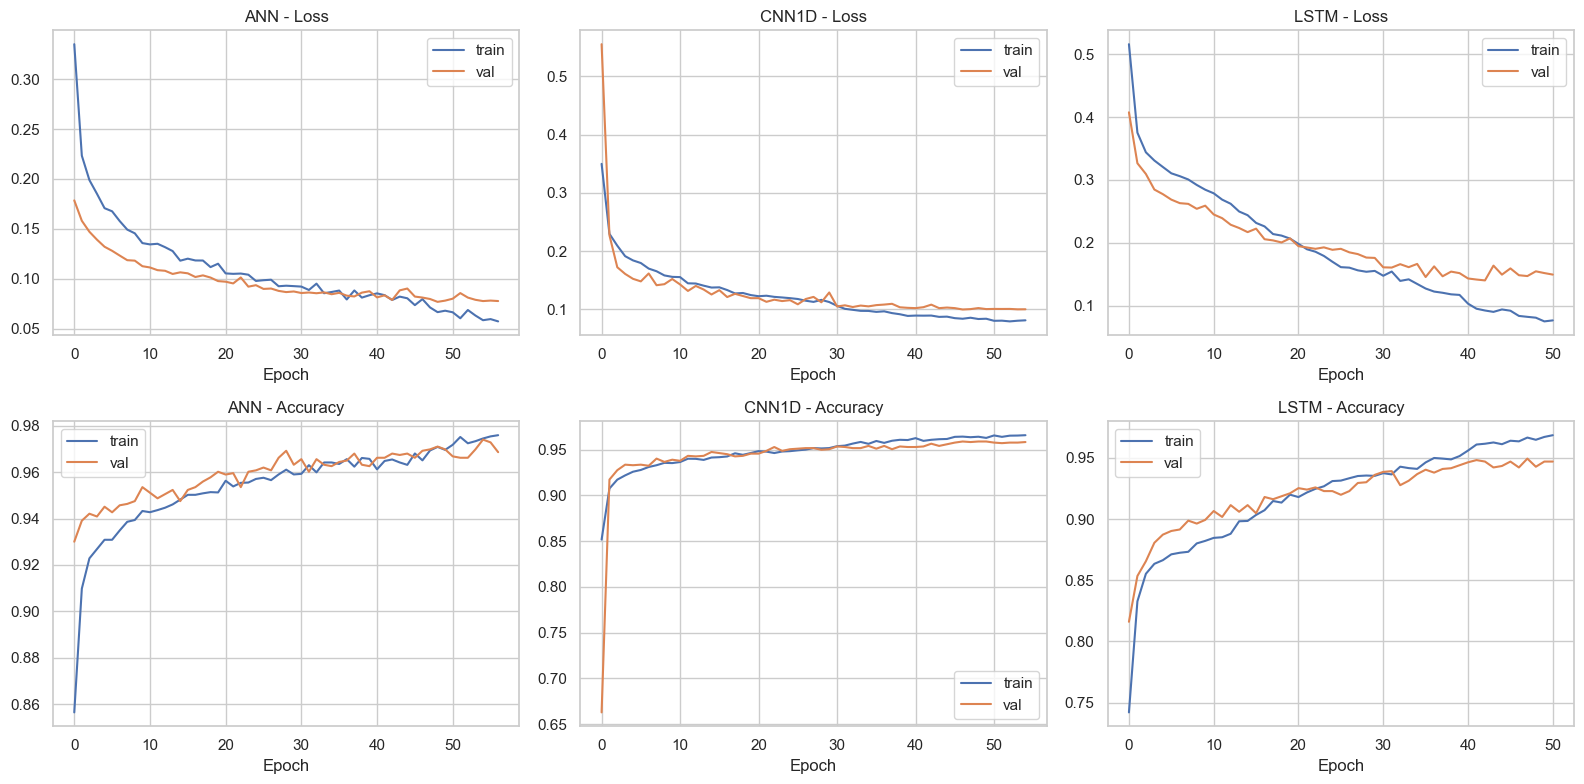

In [18]:
# Kurva training (loss & accuracy) ketiga model
histories = {"ANN": history_ann, "CNN1D": history_cnn, "LSTM": history_lstm}

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, (name, h) in enumerate(histories.items()):
    axes[0, i].plot(h.history["loss"], label="train")
    axes[0, i].plot(h.history["val_loss"], label="val")
    axes[0, i].set_title(f"{name} - Loss")
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].legend()

    axes[1, i].plot(h.history["accuracy"], label="train")
    axes[1, i].plot(h.history["val_accuracy"], label="val")
    axes[1, i].set_title(f"{name} - Accuracy")
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].legend()

plt.tight_layout()
plt.savefig("assets_training_curves.png", bbox_inches="tight")
plt.show()

## 7. Evaluasi Kinerja Masing-Masing Model

Untuk setiap model dihitung **Confusion Matrix** (TP, TN, FP, FN) dengan kelas positif = **Phishing (1)**,
lalu diturunkan 7 metrik:

- **a. TPR (Recall/Sensitivity)** = TP / (TP + FN)
- **b. TNR (Specificity)** = TN / (TN + FP)
- **c. FPR** = FP / (FP + TN)
- **d. FNR** = FN / (FN + TP)
- **e. PPV (Precision)** = TP / (TP + FP)
- **f. NPV** = TN / (TN + FN)
- **g. Accuracy** = (TP + TN) / (TP + TN + FP + FN)

In [19]:
MODELS = {
    "ANN": (ann_model, X_test_scaled),
    "CNN1D": (cnn_model, X_test_seq),
    "LSTM": (lstm_model, X_test_seq),
}

def evaluate_model(model, X_eval, y_true, threshold=0.5):
    """Prediksi & hitung confusion matrix + 7 metrik evaluasi.
    Kelas positif (1) = Phishing, kelas negatif (0) = Legitimate.
    """
    y_prob = model.predict(X_eval, verbose=0).ravel()
    y_pred = (y_prob >= threshold).astype(int)

    # confusion_matrix sklearn: baris = actual, kolom = predicted, urutan label [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall / Sensitivity
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Specificity
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0   # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    return {
        "y_prob": y_prob, "y_pred": y_pred, "cm": cm,
        "TP": int(tp), "TN": int(tn), "FP": int(fp), "FN": int(fn),
        "TPR": tpr, "TNR": tnr, "FPR": fpr, "FNR": fnr,
        "PPV": ppv, "NPV": npv, "Accuracy": accuracy,
    }

results = {}
for name, (model, X_eval) in MODELS.items():
    results[name] = evaluate_model(model, X_eval, y_test)
    r = results[name]
    print(f"\n===== {name} =====")
    print(f"TP={r['TP']}  TN={r['TN']}  FP={r['FP']}  FN={r['FN']}")
    print(f"Accuracy={r['Accuracy']:.4f}  TPR={r['TPR']:.4f}  TNR={r['TNR']:.4f}  "
          f"FPR={r['FPR']:.4f}  FNR={r['FNR']:.4f}  PPV={r['PPV']:.4f}  NPV={r['NPV']:.4f}")


===== ANN =====
TP=704  TN=909  FP=15  FN=31
Accuracy=0.9723  TPR=0.9578  TNR=0.9838  FPR=0.0162  FNR=0.0422  PPV=0.9791  NPV=0.9670

===== CNN1D =====
TP=701  TN=891  FP=33  FN=34
Accuracy=0.9596  TPR=0.9537  TNR=0.9643  FPR=0.0357  FNR=0.0463  PPV=0.9550  NPV=0.9632

===== LSTM =====
TP=688  TN=895  FP=29  FN=47
Accuracy=0.9542  TPR=0.9361  TNR=0.9686  FPR=0.0314  FNR=0.0639  PPV=0.9596  NPV=0.9501


In [20]:
# Tabel ringkasan seluruh metrik ketiga model
metrics_df = pd.DataFrame({
    name: {
        "Accuracy": r["Accuracy"], "TPR (Recall)": r["TPR"], "TNR (Specificity)": r["TNR"],
        "FPR": r["FPR"], "FNR": r["FNR"], "PPV (Precision)": r["PPV"], "NPV": r["NPV"],
        "TP": r["TP"], "TN": r["TN"], "FP": r["FP"], "FN": r["FN"],
    }
    for name, r in results.items()
}).T

metrics_df_display = metrics_df.copy()
for col in ["Accuracy", "TPR (Recall)", "TNR (Specificity)", "FPR", "FNR", "PPV (Precision)", "NPV"]:
    metrics_df_display[col] = (metrics_df_display[col] * 100).round(2)

metrics_df_display

,Accuracy,TPR (Recall),TNR (Specificity),FPR,FNR,PPV (Precision),NPV,TP,TN,FP,FN
ANN,97.23,95.78,98.38,1.62,4.22,97.91,96.70,704.0,909.0,15.0,31.0
CNN1D,95.96,95.37,96.43,3.57,4.63,95.50,96.32,701.0,891.0,33.0,34.0
LSTM,95.42,93.61,96.86,3.14,6.39,95.96,95.01,688.0,895.0,29.0,47.0


In [21]:
metrics_df.to_csv("evaluation_metrics_summary.csv")
print("Ringkasan metrik disimpan ke evaluation_metrics_summary.csv")

Ringkasan metrik disimpan ke evaluation_metrics_summary.csv


In [22]:
# classification_report tambahan (opsional, untuk validasi silang angka di atas)
for name, (model, X_eval) in MODELS.items():
    print(f"\n===== Classification Report: {name} =====")
    print(classification_report(y_test, results[name]["y_pred"],
                                 target_names=["Legitimate (0)", "Phishing (1)"], digits=4))


===== Classification Report: ANN =====
                precision    recall  f1-score   support

Legitimate (0)     0.9670    0.9838    0.9753       924
  Phishing (1)     0.9791    0.9578    0.9684       735

      accuracy                         0.9723      1659
     macro avg     0.9731    0.9708    0.9718      1659
  weighted avg     0.9724    0.9723    0.9722      1659


===== Classification Report: CNN1D =====
                precision    recall  f1-score   support

Legitimate (0)     0.9632    0.9643    0.9638       924
  Phishing (1)     0.9550    0.9537    0.9544       735

      accuracy                         0.9596      1659
     macro avg     0.9591    0.9590    0.9591      1659
  weighted avg     0.9596    0.9596    0.9596      1659


===== Classification Report: LSTM =====
                precision    recall  f1-score   support

Legitimate (0)     0.9501    0.9686    0.9593       924
  Phishing (1)     0.9596    0.9361    0.9477       735

      accuracy               

## 8. Visualisasi Perbandingan Model

### a. Confusion Matrix Heatmap (3 buah — satu per model)

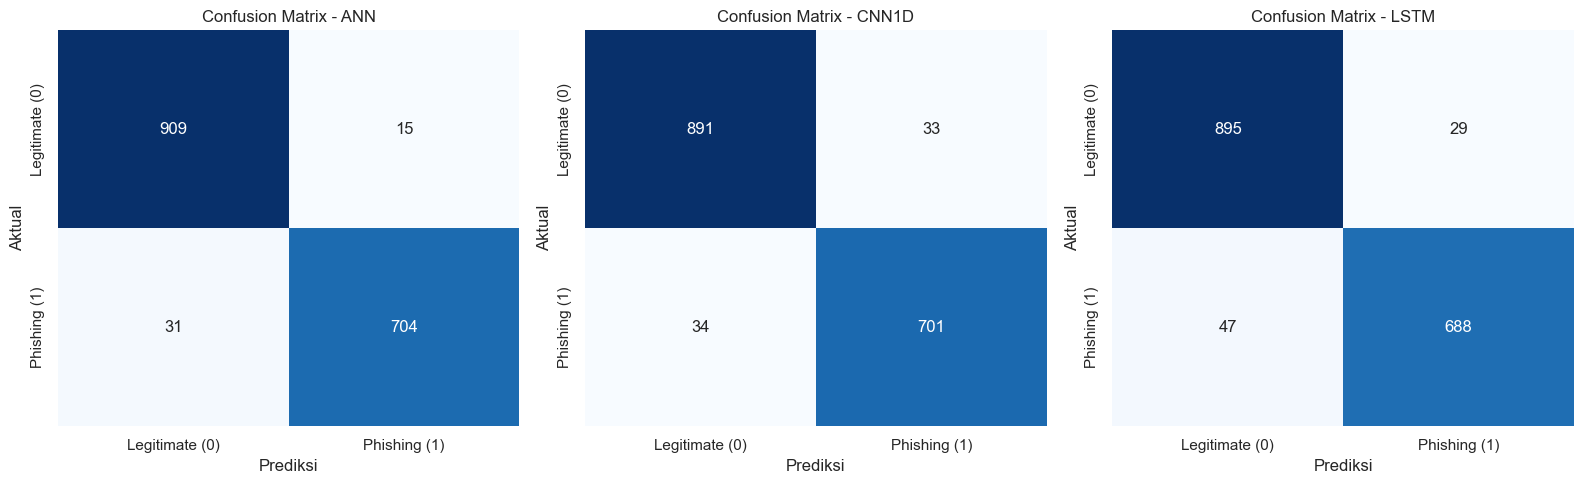

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
cm_labels = ["Legitimate (0)", "Phishing (1)"]
for ax, (name, r) in zip(axes, results.items()):
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=cm_labels, yticklabels=cm_labels, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Prediksi")
    ax.set_ylabel("Aktual")
plt.tight_layout()
plt.savefig("assets_confusion_matrices.png", bbox_inches="tight")
plt.show()

### b–g. Bar Chart Perbandingan Tiap Metrik (Accuracy, TPR, TNR, FPR, FNR, PPV, NPV)

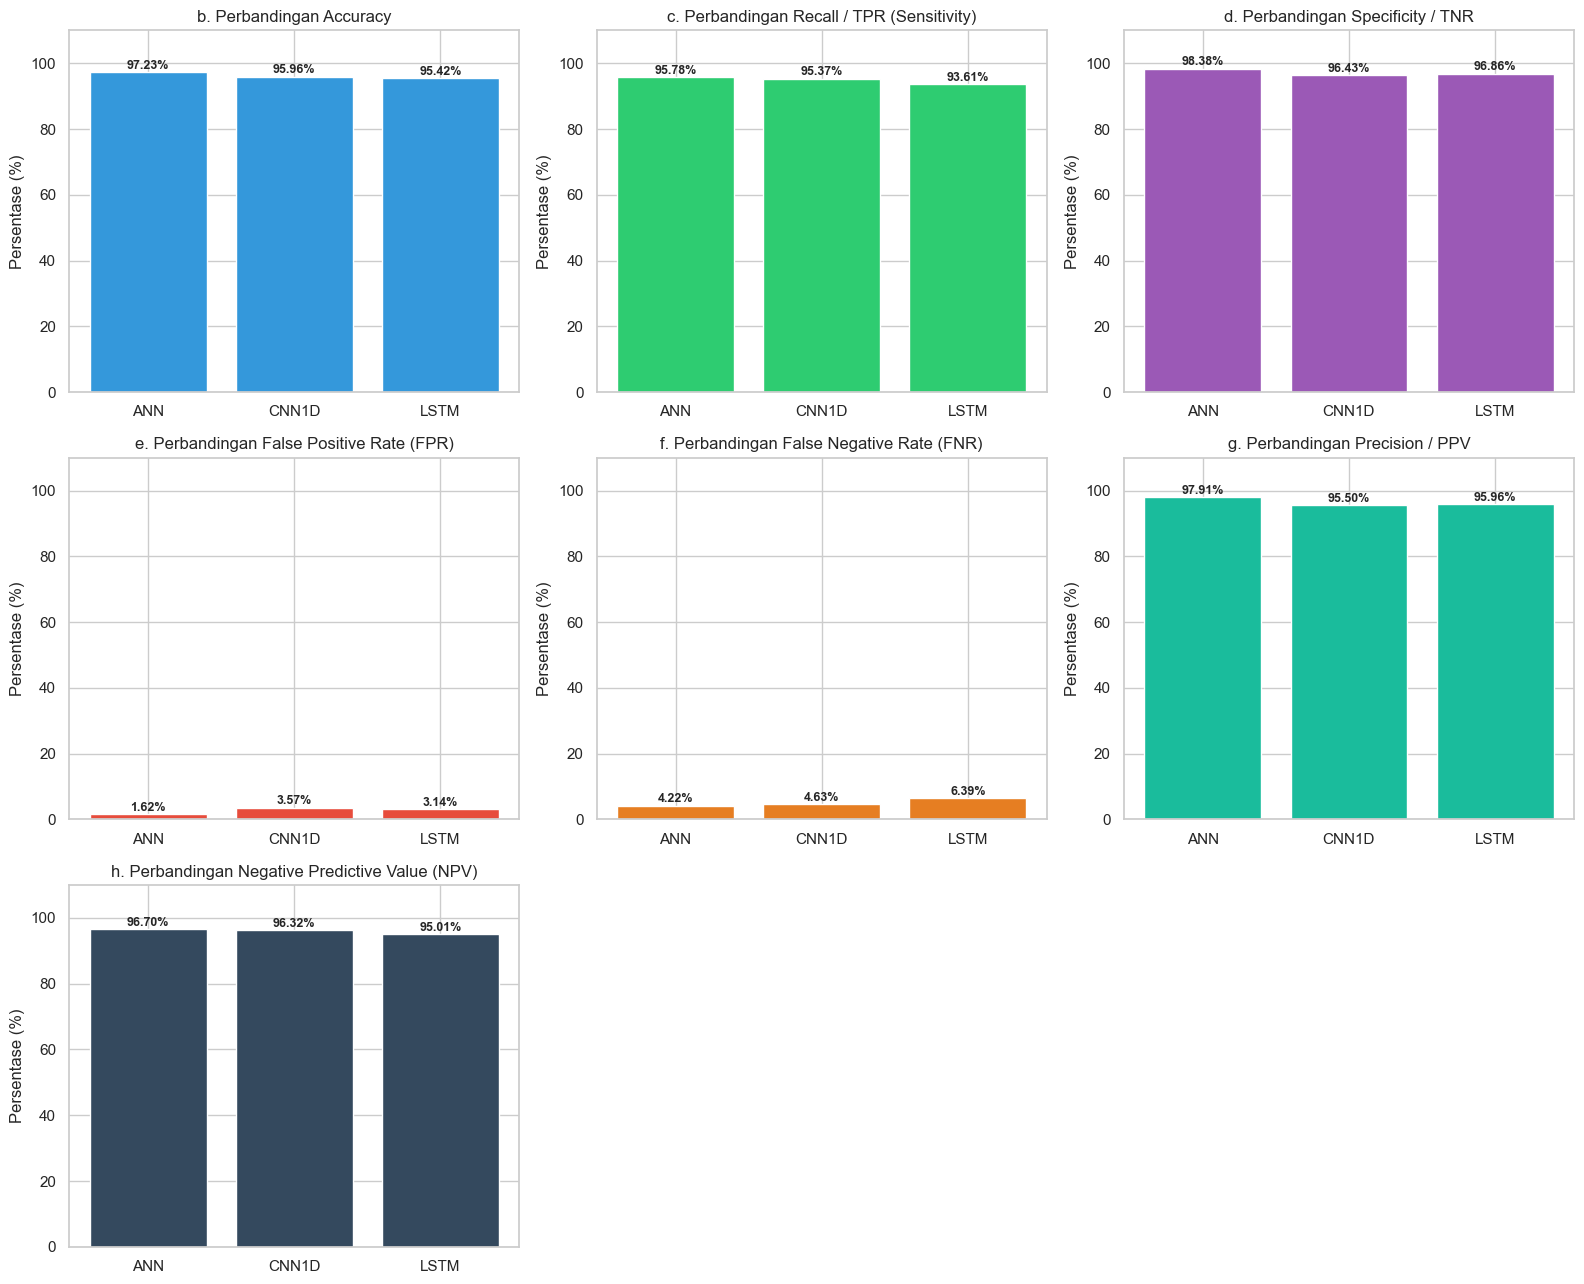

In [24]:
def plot_metric_comparison(metric_key, title, ax, color):
    values = [results[m][metric_key] * 100 for m in MODELS.keys()]
    bars = ax.bar(list(MODELS.keys()), values, color=color)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.2f}%",
                ha="center", fontweight="bold", fontsize=9)
    ax.set_title(title)
    ax.set_ylabel("Persentase (%)")
    ax.set_ylim(0, 110)

metric_specs = [
    ("Accuracy", "b. Perbandingan Accuracy", "#3498db"),
    ("TPR", "c. Perbandingan Recall / TPR (Sensitivity)", "#2ecc71"),
    ("TNR", "d. Perbandingan Specificity / TNR", "#9b59b6"),
    ("FPR", "e. Perbandingan False Positive Rate (FPR)", "#e74c3c"),
    ("FNR", "f. Perbandingan False Negative Rate (FNR)", "#e67e22"),
    ("PPV", "g. Perbandingan Precision / PPV", "#1abc9c"),
    ("NPV", "h. Perbandingan Negative Predictive Value (NPV)", "#34495e"),
]

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.ravel()
for ax, (key, title, color) in zip(axes, metric_specs):
    plot_metric_comparison(key, title, ax, color)
for ax in axes[len(metric_specs):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig("assets_metric_bar_charts.png", bbox_inches="tight")
plt.show()

### i. Grouped Bar Chart — Seluruh Metrik (TPR, TNR, FPR, FNR, PPV, NPV, Accuracy) Ketiga Model Sekaligus

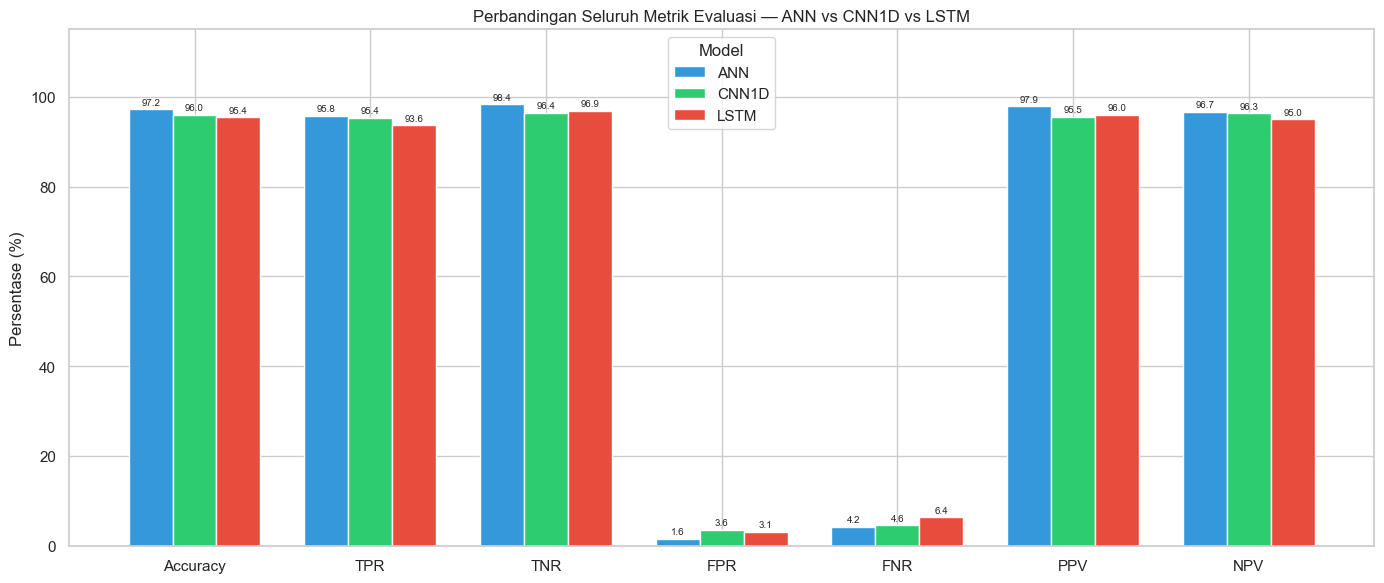

In [25]:
all_metric_keys = ["Accuracy", "TPR", "TNR", "FPR", "FNR", "PPV", "NPV"]
model_names = list(MODELS.keys())

x = np.arange(len(all_metric_keys))
width = 0.25
fig, ax = plt.subplots(figsize=(14, 6))

palette = ["#3498db", "#2ecc71", "#e74c3c"]
for i, name in enumerate(model_names):
    values = [results[name][k] * 100 for k in all_metric_keys]
    bars = ax.bar(x + (i - 1) * width, values, width, label=name, color=palette[i])
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 1, f"{v:.1f}",
                ha="center", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(all_metric_keys)
ax.set_ylabel("Persentase (%)")
ax.set_ylim(0, 115)
ax.set_title("Perbandingan Seluruh Metrik Evaluasi — ANN vs CNN1D vs LSTM")
ax.legend(title="Model")
plt.tight_layout()
plt.savefig("assets_all_metrics_grouped.png", bbox_inches="tight")
plt.show()

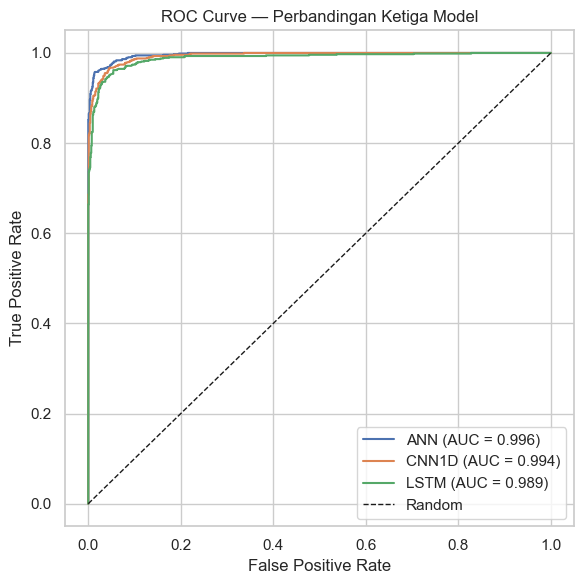

In [26]:
# ROC Curve ketiga model sebagai visualisasi tambahan (opsional, memperkuat evaluasi)
fig, ax = plt.subplots(figsize=(6, 6))
for name, r in results.items():
    fpr_curve, tpr_curve, _ = roc_curve(y_test, r["y_prob"])
    roc_auc = auc(fpr_curve, tpr_curve)
    ax.plot(fpr_curve, tpr_curve, label=f"{name} (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Perbandingan Ketiga Model")
ax.legend()
plt.tight_layout()
plt.savefig("assets_roc_curve.png", bbox_inches="tight")
plt.show()

## 9. Memilih Model Terbaik & Menyimpan Artefak

Model terbaik dipilih berdasarkan **Accuracy** tertinggi pada test set (dengan F1/PPV & TPR
sebagai pertimbangan tambahan bila accuracy berdekatan). Ketiga model tetap disimpan semua
agar aplikasi web bisa menampilkan **perbandingan prediksi ketiga model** sekaligus.

In [27]:
best_model_name = metrics_df["Accuracy"].astype(float).idxmax()
print(f"Model dengan Accuracy tertinggi pada test set: **{best_model_name}**")
print(metrics_df_display.loc[best_model_name])

Model dengan Accuracy tertinggi pada test set: **ANN**
Accuracy              97.23
TPR (Recall)          95.78
TNR (Specificity)     98.38
FPR                    1.62
FNR                    4.22
PPV (Precision)       97.91
NPV                   96.70
TP                   704.00
TN                   909.00
FP                    15.00
FN                    31.00
Name: ANN, dtype: float64


In [28]:
# Simpan ketiga model dalam format .keras (native Keras 3), StandardScaler, urutan fitur,
# dan ringkasan metrik — semua akan dipakai oleh aplikasi Streamlit di folder streamlit_app/.
model_objs = {"ANN": ann_model, "CNN1D": cnn_model, "LSTM": lstm_model}
for name, model in model_objs.items():
    path = os.path.join(ARTIFACT_DIR, f"best_{name}.keras")
    model.save(path)
    print("Tersimpan:", path)

joblib.dump(scaler, os.path.join(ARTIFACT_DIR, "scaler.pkl"))

with open(os.path.join(ARTIFACT_DIR, "feature_columns.json"), "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

with open(os.path.join(ARTIFACT_DIR, "model_info.json"), "w") as f:
    json.dump({
        "best_model": best_model_name,
        "n_features": n_features,
        "positive_class_meaning": "1 = Phishing, 0 = Legitimate",
        "metrics": {k: {mk: float(mv) for mk, mv in v.items() if mk not in ("y_prob", "y_pred", "cm")}
                    for k, v in results.items()},
    }, f, indent=2)

metrics_df.to_csv(os.path.join(ARTIFACT_DIR, "evaluation_metrics_summary.csv"))

print("\nSemua artefak (model, scaler, feature_columns.json, model_info.json) berhasil disimpan ke:",
      ARTIFACT_DIR)

Tersimpan: streamlit_app/models\best_ANN.keras
Tersimpan: streamlit_app/models\best_CNN1D.keras
Tersimpan: streamlit_app/models\best_LSTM.keras

Semua artefak (model, scaler, feature_columns.json, model_info.json) berhasil disimpan ke: streamlit_app/models


## 10. Kesimpulan

- Ketiga arsitektur Deep Learning (**ANN**, **CNN1D**, **LSTM**) berhasil dilatih untuk
  mengklasifikasikan website sebagai phishing atau legitimate berdasarkan 30 fitur URL/website.
- Evaluasi menggunakan Confusion Matrix beserta 7 metrik turunannya (Accuracy, TPR, TNR, FPR,
  FNR, PPV, NPV) memberikan gambaran menyeluruh — tidak hanya accuracy — termasuk seberapa
  sering model **salah melewatkan situs phishing (FNR)** dan **salah menandai situs aman
  sebagai phishing (FPR)**, dua hal yang sama pentingnya dalam konteks keamanan.
- Model dengan performa terbaik pada notebook ini disimpan sebagai referensi (`best_model_name`
  di atas), namun ketiga model tetap disimpan agar dapat dibandingkan langsung di aplikasi web.
- Artefak (`.keras`, `scaler.pkl`, `feature_columns.json`, `model_info.json`) siap dipakai oleh
  aplikasi Streamlit di folder `streamlit_app/` untuk mendeteksi URL yang dimasukkan pengguna
  secara real-time.